In [18]:
from PIL import Image
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import time
from skimage.transform import resize
from skimage.io import imsave, imread
from scipy import ndimage
import scipy.optimize as opt
from scipy.ndimage import gaussian_filter
from scipy.ndimage import label

(480, 640, 3)


(-0.5, 639.5, 479.5, -0.5)

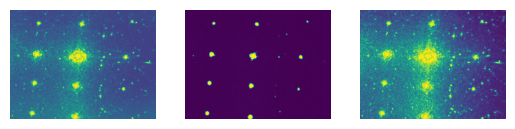

In [19]:
image = Image.open('Grid_test_images/test-1.jpg')
image_array = np.array(image)

print(image_array.shape)
plt.subplot(1,3 ,1)
plt.imshow(image_array[:, :, 0])
plt.axis("off")
plt.subplot(1,3 ,2)
plt.imshow(image_array[:, :, 1])
plt.axis("off")
plt.subplot(1,3 ,3)
plt.imshow(image_array[:, :, 2])
plt.axis("off")

In [20]:
# image = Image.open('gird_test_images/test-3.jpg')
# image_array = np.array(image)

# print(image_array.shape)
# plt.subplot(1,3 ,1)
# plt.imshow(image_array[:, :, 0])
# plt.axis("off")
# plt.subplot(1,3 ,2)
# plt.imshow(image_array[:, :, 1])
# plt.axis("off")
# plt.subplot(1,3 ,3)
# plt.imshow(image_array[:, :, 2])
# plt.axis("off")

In [21]:
def find_centre_gaus(image_array):
    image_array_max = (image_array <= image_array.max()) & (image_array > (image_array.max() - image_array.max()/8))
    index_horizontal = np.array(range(0, image_array_max.shape[1]))
    image_array_weighted_horizontal = index_horizontal * image_array_max
    image_array_weighted_horizontal_filtered = image_array_weighted_horizontal[image_array_weighted_horizontal > 0]
    avg_horizontal = np.average(image_array_weighted_horizontal_filtered)
    # print("horizontal: ", avg_horizontal)

    index_vetical = np.array(range(0, image_array_max.shape[0]))
    image_array_weighted_vetical = index_vetical * image_array_max.transpose() # transposed to rotate 90 degrees
    image_array_weighted_vetical_filtered = image_array_weighted_vetical[image_array_weighted_vetical > 0]
    avg_vetical = np.average(image_array_weighted_vetical_filtered)
    # print("vertical: ", avg_vetical)

    blurred_image = gaussian_filter(image_array, sigma=3)
    blurred_image_max = (blurred_image <= blurred_image.max()) & (blurred_image > (blurred_image.max() - blurred_image.max()/8))
    
    # print("image array")
    # plt.imshow(image_array)
    # plt.show()
    # plt.figure()
    # plt.scatter(avg_horizontal, avg_vetical, color="red", s=4)
                
    # print("image array max threshold")
    # plt.imshow(image_array_max)
    # plt.show()
    # plt.scatter(avg_horizontal, avg_vetical, color="red", s=4)

    # print("blurred image")
    # plt.imshow(blurred_image)
    # plt.show()

    # print("blurred array max threshold")
    # plt.imshow(blurred_image_max)
    # plt.show()


    return avg_horizontal, avg_vetical

In [22]:
image_array_original = image_array

single channel centre finding
x_center:  255.82171799027552   y_center:  269.26418152350084


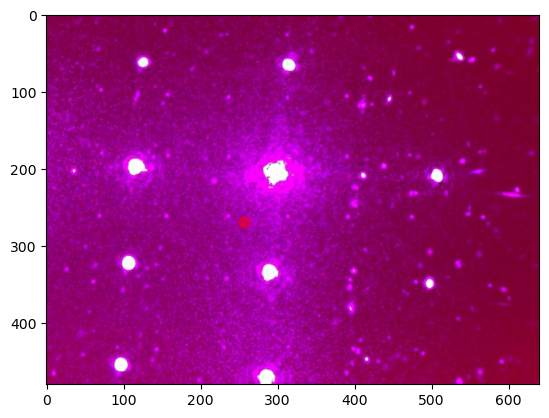

In [23]:
print("single channel centre finding")
# x_curve, y_curve = curve_fitting(image_array=image_array)
x_center, y_center = find_centre_gaus(image_array=image_array_original[:,:,1])

print("x_center: ", x_center, "  y_center: ", y_center)
# print("x_curve: ", x_curve, "  y_curve: ", y_curve)

plt.imshow(image_array)
plt.scatter(x_center, y_center, s=60, color="red", alpha=0.5)
# plt.scatter(x_curve, y_curve, s=30, color="blue", alpha=0.5)

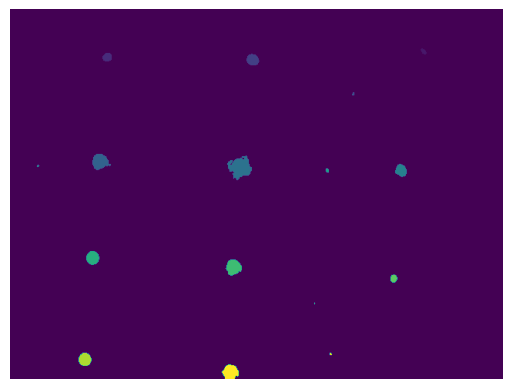

,index,centre_horizontal,centre_vertical,size,radius_approximation
5,6,298.137987,205.129870,616,14.002817
4,5,116.653846,197.677515,338,10.372499
10,11,289.845426,334.659306,317,10.045110
15,16,285.833866,470.549521,313,9.981533
9,10,106.911017,322.427966,236,8.667245
13,14,96.829694,454.183406,229,8.537738
2,3,314.664921,65.455497,191,7.797255
6,7,507.271739,209.081522,184,7.653040


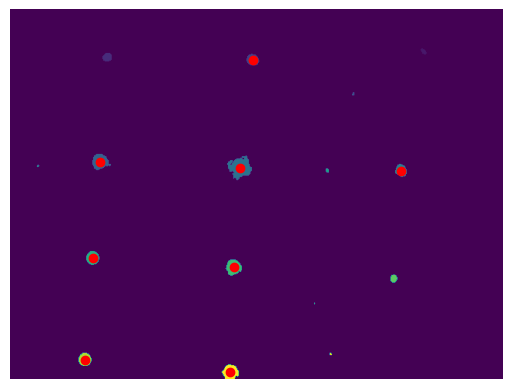

In [24]:
image_array = image_array_original[:,:,1]
image_array_max = (image_array <= image_array.max()) & (image_array > (image_array.max() - image_array.max()/4))

image_array_max

labeled_array, num_features = label(image_array_max)
# we can now find the centre of mass (and total mass) of each cluster
plt.imshow(labeled_array)
plt.axis('off')
plt.show()


cluster_indexes = np.unique(labeled_array)
clusters_df = pd.DataFrame(cluster_indexes[1:], columns=["index"])
clusters_df[["centre_horizontal", "centre_vertical"]] = clusters_df["index"].apply(lambda x: pd.Series(find_centre_gaus(labeled_array == x)))
clusters_df["size"] = clusters_df["index"].apply(lambda x: (labeled_array == x).sum())
clusters_df["radius_approximation"] = np.sqrt(clusters_df["size"]/np.pi)

clusters_df = clusters_df[clusters_df["radius_approximation"] > clusters_df["radius_approximation"].max()/2]

clusters_df.sort_values(by="size", ascending=False, inplace=True)

plt.imshow(labeled_array)
plt.scatter(clusters_df["centre_horizontal"], clusters_df["centre_vertical"], color="r")
plt.axis('off')
clusters_df

In [25]:
clusters_df["is_centre"] = clusters_df["size"] == clusters_df["size"].max()
clusters_df

,index,centre_horizontal,centre_vertical,size,radius_approximation,is_centre
5,6,298.137987,205.129870,616,14.002817,True
4,5,116.653846,197.677515,338,10.372499,False
10,11,289.845426,334.659306,317,10.045110,False
15,16,285.833866,470.549521,313,9.981533,False
9,10,106.911017,322.427966,236,8.667245,False
13,14,96.829694,454.183406,229,8.537738,False
2,3,314.664921,65.455497,191,7.797255,False
6,7,507.271739,209.081522,184,7.653040,False


,index,centre_horizontal,centre_vertical,size,radius_approximation,is_centre,is_above,is_below,is_left,is_right
5,6,298.137987,205.129870,616,14.002817,True,False,False,False,False
4,5,116.653846,197.677515,338,10.372499,False,False,False,True,False
10,11,289.845426,334.659306,317,10.045110,False,False,True,False,False
15,16,285.833866,470.549521,313,9.981533,False,False,True,False,False
9,10,106.911017,322.427966,236,8.667245,False,False,False,False,False
13,14,96.829694,454.183406,229,8.537738,False,False,False,False,False
2,3,314.664921,65.455497,191,7.797255,False,True,False,False,False
6,7,507.271739,209.081522,184,7.653040,False,False,False,False,True


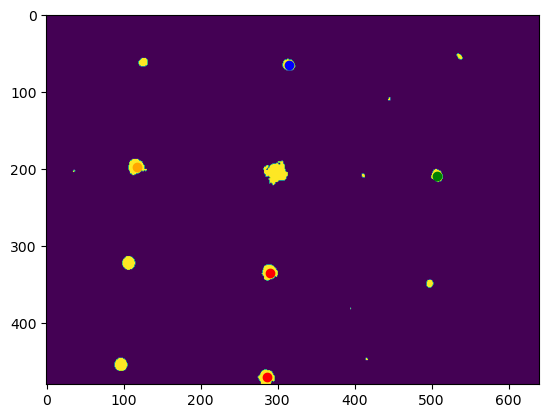

In [26]:
def is_above(centre_x, centre_y, target_x, target_y, margin):
    if np.abs(centre_x - target_x) > margin:
        return False
    if centre_y <= target_y:
        return False
    return True

def is_below(centre_x, centre_y, target_x, target_y, margin):
    if np.abs(centre_x - target_x) > margin:
        return False
    if centre_y >= target_y:
        return False
    return True

def is_left(centre_x, centre_y, target_x, target_y, margin):
    if np.abs(centre_y - target_y) > margin:
        return False
    if centre_x <= target_x:
        return False
    return True

def is_right(centre_x, centre_y, target_x, target_y, margin):
    if np.abs(centre_y - target_y) > margin:
        return False
    if centre_x >= target_x:
        return False
    return True

    
centre_x = clusters_df[clusters_df["is_centre"] == True].iloc[0]["centre_horizontal"]
centre_y = clusters_df[clusters_df["is_centre"] == True].iloc[0]["centre_vertical"]
clusters_df["is_above"] = clusters_df.apply(lambda x: is_above(centre_x=centre_x, 
                                                               centre_y=centre_y,
                                                               target_x=x["centre_horizontal"],
                                                               target_y=x["centre_vertical"],
                                                               margin=30), axis=1)

clusters_df["is_below"] = clusters_df.apply(lambda x: is_below(centre_x=centre_x, 
                                                               centre_y=centre_y,
                                                               target_x=x["centre_horizontal"],
                                                               target_y=x["centre_vertical"],
                                                               margin=30), axis=1)

clusters_df["is_left"] = clusters_df.apply(lambda x: is_left(centre_x=centre_x, 
                                                               centre_y=centre_y,
                                                               target_x=x["centre_horizontal"],
                                                               target_y=x["centre_vertical"],
                                                               margin=30), axis=1)

clusters_df["is_right"] = clusters_df.apply(lambda x: is_right(centre_x=centre_x, 
                                                               centre_y=centre_y,
                                                               target_x=x["centre_horizontal"],
                                                               target_y=x["centre_vertical"],
                                                               margin=30), axis=1)

plt.imshow(image_array_max)
plt.scatter(clusters_df[clusters_df["is_above"] == True]["centre_horizontal"], clusters_df[clusters_df["is_above"] == True]["centre_vertical"], color="blue")
plt.scatter(clusters_df[clusters_df["is_below"] == True]["centre_horizontal"], clusters_df[clusters_df["is_below"] == True]["centre_vertical"], color="red")
plt.scatter(clusters_df[clusters_df["is_left"] == True]["centre_horizontal"], clusters_df[clusters_df["is_left"] == True]["centre_vertical"], color="orange")
plt.scatter(clusters_df[clusters_df["is_right"] == True]["centre_horizontal"], clusters_df[clusters_df["is_right"] == True]["centre_vertical"], color="green")
clusters_df

,index,centre_horizontal,centre_vertical,size,radius_approximation,is_centre,is_above,is_below,is_left,is_right
5,6,298.137987,205.129870,616,14.002817,True,False,False,False,False
4,5,116.653846,197.677515,338,10.372499,False,False,False,True,False
10,11,289.845426,334.659306,317,10.045110,False,False,True,False,False
2,3,314.664921,65.455497,191,7.797255,False,True,False,False,False
6,7,507.271739,209.081522,184,7.653040,False,False,False,False,True


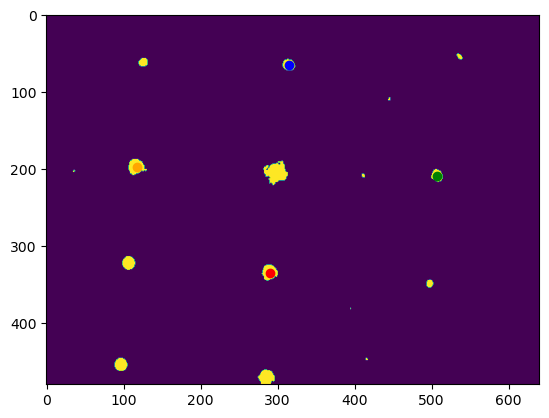

In [27]:
# Now filter to find only peaks closest to center in each direction
clusters_df["is_above"] = np.where(
    (clusters_df["is_above"] == True) & (clusters_df["centre_vertical"] == clusters_df[clusters_df["is_above"] == True]["centre_vertical"].max())
, True, False)

clusters_df["is_below"] = np.where(
    (clusters_df["is_below"] == True) & (clusters_df["centre_vertical"] == clusters_df[clusters_df["is_below"] == True]["centre_vertical"].min())
, True, False)

clusters_df["is_left"] = np.where(
    (clusters_df["is_left"] == True) & (clusters_df["centre_horizontal"] == clusters_df[clusters_df["is_left"] == True]["centre_horizontal"].max())
, True, False)

clusters_df["is_right"] = np.where(
    (clusters_df["is_right"] == True) & (clusters_df["centre_horizontal"] == clusters_df[clusters_df["is_right"] == True]["centre_horizontal"].min())
, True, False)

plt.imshow(image_array_max)
plt.scatter(clusters_df[clusters_df["is_above"] == True]["centre_horizontal"], clusters_df[clusters_df["is_above"] == True]["centre_vertical"], color="blue")
plt.scatter(clusters_df[clusters_df["is_below"] == True]["centre_horizontal"], clusters_df[clusters_df["is_below"] == True]["centre_vertical"], color="red")
plt.scatter(clusters_df[clusters_df["is_left"] == True]["centre_horizontal"], clusters_df[clusters_df["is_left"] == True]["centre_vertical"], color="orange")
plt.scatter(clusters_df[clusters_df["is_right"] == True]["centre_horizontal"], clusters_df[clusters_df["is_right"] == True]["centre_vertical"], color="green")
clusters_df

clusters_df_filtered = clusters_df[
    (clusters_df["is_centre"] == True) |
    (clusters_df["is_above"] == True) |
    (clusters_df["is_below"] == True) |
    (clusters_df["is_left"] == True) |
    (clusters_df["is_right"] == True)
]

clusters_df_filtered

301.97576951618714, 203.0879492335962


,index,centre_horizontal,centre_vertical,size,radius_approximation,is_centre,is_above,is_below,is_left,is_right
5,6,298.137987,205.129870,616,14.002817,True,False,False,False,False
4,5,116.653846,197.677515,338,10.372499,False,False,False,True,False
10,11,289.845426,334.659306,317,10.045110,False,False,True,False,False
15,16,285.833866,470.549521,313,9.981533,False,False,False,False,False
9,10,106.911017,322.427966,236,8.667245,False,False,False,False,False
13,14,96.829694,454.183406,229,8.537738,False,False,False,False,False
2,3,314.664921,65.455497,191,7.797255,False,True,False,False,False
6,7,507.271739,209.081522,184,7.653040,False,False,False,False,True


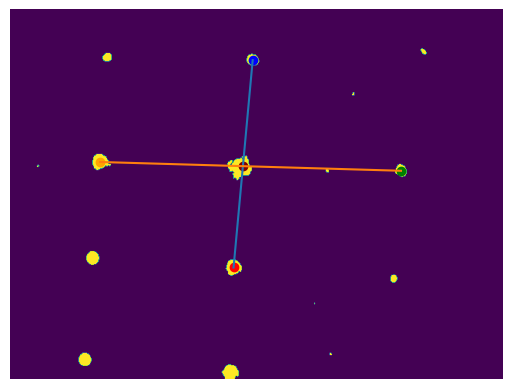

In [ ]:
# Find centre using intersection
x1 = clusters_df_filtered[clusters_df_filtered["is_above"] == True].iloc[0]["centre_horizontal"]
y1 = clusters_df_filtered[clusters_df_filtered["is_above"] == True].iloc[0]["centre_vertical"]
x2 = clusters_df_filtered[clusters_df_filtered["is_below"] == True].iloc[0]["centre_horizontal"]
y2 = clusters_df_filtered[clusters_df_filtered["is_below"] == True].iloc[0]["centre_vertical"]

x3 = clusters_df_filtered[clusters_df_filtered["is_left"] == True].iloc[0]["centre_horizontal"]
y3 = clusters_df_filtered[clusters_df_filtered["is_left"] == True].iloc[0]["centre_vertical"]
x4 = clusters_df_filtered[clusters_df_filtered["is_right"] == True].iloc[0]["centre_horizontal"]
y4 = clusters_df_filtered[clusters_df_filtered["is_right"] == True].iloc[0]["centre_vertical"]

vertical_line_gradient = (y2-y1)/(x2-x1)
vertical_line_intercept = y1 - vertical_line_gradient * x1

horizontal_line_gradient = (y3-y4)/(x3-x4)
horizontal_line_intercept = y3 - horizontal_line_gradient * x3

x = (vertical_line_intercept - horizontal_line_intercept) / (horizontal_line_gradient - vertical_line_gradient)
y = (vertical_line_gradient * x) + vertical_line_intercept
print(f"{x}, {y}")

plt.imshow(image_array_max)
plt.plot([clusters_df[clusters_df["is_above"] == True]["centre_horizontal"] , clusters_df[clusters_df["is_below"] == True]["centre_horizontal"]], [clusters_df[clusters_df["is_above"] == True]["centre_vertical"] , clusters_df[clusters_df["is_below"] == True]["centre_vertical"]])
plt.plot([clusters_df[clusters_df["is_left"] == True]["centre_horizontal"] , clusters_df[clusters_df["is_right"] == True]["centre_horizontal"]], [clusters_df[clusters_df["is_left"] == True]["centre_vertical"] , clusters_df[clusters_df["is_right"] == True]["centre_vertical"]])
plt.scatter(clusters_df[clusters_df["is_above"] == True]["centre_horizontal"], clusters_df[clusters_df["is_above"] == True]["centre_vertical"], color="blue")
plt.scatter(clusters_df[clusters_df["is_below"] == True]["centre_horizontal"], clusters_df[clusters_df["is_below"] == True]["centre_vertical"], color="red")
plt.scatter(clusters_df[clusters_df["is_left"] == True]["centre_horizontal"], clusters_df[clusters_df["is_left"] == True]["centre_vertical"], color="orange")
plt.scatter(clusters_df[clusters_df["is_right"] == True]["centre_horizontal"], clusters_df[clusters_df["is_right"] == True]["centre_vertical"], color="green")
plt.scatter(clusters_df[clusters_df["is_centre"] == True]["centre_horizontal"], clusters_df[clusters_df["is_centre"] == True]["centre_vertical"], color="magenta")
plt.scatter(x,y, color="maroon")
plt.axis('off')
clusters_df

# Test case

In [29]:
import numpy as np
from scipy.ndimage import label

arr = np.array([
    [0,0,1,1,0],
    [0,0,1,1,0],
    [1,1,0,0,0]
])

# 1. Group the separate circles
labeled_array, num_features = label(arr)

# 2. Use np.where to find all indices
# This gives us (all_rows, all_cols)
rows, cols = np.where(arr)

# 3. Use grouping logic to split them by label
# We extract the label ID for every 'True' pixel found
pixel_labels = labeled_array[rows, cols]

# We sort the indices by their label ID to group them
sort_idx = np.argsort(pixel_labels)
rows_sorted = rows[sort_idx]
cols_sorted = cols[sort_idx]

# Find where the label changes to split the arrays
splits = np.where(np.diff(pixel_labels[sort_idx]))[0] + 1

# Split into the format: [[rows_circle1, rows_circle2], [cols_circle1, cols_circle2]]
grouped_rows = np.split(rows_sorted, splits)
grouped_cols = np.split(cols_sorted, splits)

# Combine into your requested nested list structure
output = [[r.tolist(), c.tolist()] for r, c in zip(grouped_rows, grouped_cols)]

print(output)

[[[0, 0, 1, 1], [2, 3, 2, 3]], [[2, 2], [0, 1]]]


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16],
      dtype=int32)

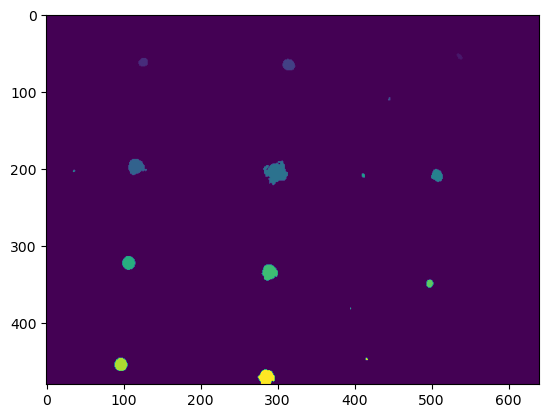

In [30]:
# 1. Group the separate circles
labeled_array, num_features = label(image_array_max)

plt.imshow(labeled_array)
np.unique(labeled_array)